In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm 
import networkx as nx
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

import pickle

%matplotlib notebook


### Load network data

In [2]:
filename = "spin_positions.pkl"
with open(filename, "rb") as fp:
    df_positions = pickle.load(fp)
    
filename = "spin_frequencies.pkl"
with open(filename, "rb") as fp:
    df_frequencies = pickle.load(fp)

filename = "spin_predicted_couplings.pkl"
with open(filename, "rb") as fp:
    df_predicted = pickle.load(fp)
    
filename = "spin_measured_couplings.pkl"
with open(filename, "rb") as fp:
    df_measured = pickle.load(fp)

filename = "spin_table.pkl"
with open(filename, "rb") as fp:
    df_table = pickle.load(fp)


### Network figure

In [3]:
# General
plt.style.use('seaborn-deep')

axes_color =  '0.8'

plt.rcParams.update({'font.size': 7,
                     'font.family':r'Arial',
                     'font.style':'normal',
                     'axes.grid' : False,
                     'axes.edgecolor': axes_color,
                     'ytick.color': '.15',
                     'xtick.color':'.15',
                     'lines.linewidth':1,

                    })

plt.rcParams['ytick.major.size'] = 3.5
plt.rcParams['ytick.major.width'] = 0.8

plt.rcParams['xtick.major.size'] = 3.5
plt.rcParams['xtick.major.width'] = 0.8

labelpad = 10

PSD_sum_color = 'lightgrey'

data_color_list = ['#588bc5', '#838bc5']

fit_alpha = 0.8

cmap_2D ='viridis' #'YlGnBu'# #'Greys'   #'OrRd'# 'YlGn' #'
cmap_2D = 'Greys'
grey_color = cm.Greys(0.5)


/var/folders/bj/yvztxw3x02q7p94lvc80kqt4f5p5j8/T/ipykernel_62938/123648199.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-deep')


In [4]:

freqs = np.zeros(len(df_frequencies.index))
for i, index in enumerate(df_frequencies.index):
    freqs[i] = df_frequencies['$A_i$ (kHz)'][i]*1e3

c_matrix = np.array(df_predicted)
    
delta_f  = 30e3
freq_min = 432e3 - delta_f /2
freq_max = 432e3 + delta_f /2

r_min = 1#88\n",
r_max = 254#195\n",
drdf = (r_max - r_min)/ (freq_max-freq_min)

g = 139
b = 197
alpha = 1.

node_colors = []
for i, freq in enumerate(freqs):
    if freq > freq_max: r = r_max
    elif freq < freq_min: r = r_min
    else: r = r_min + drdf*(freq - freq_min)
    node_colors.append([r/255,g/255,b/255,alpha])

N_steps_bar = 100
node_colors_bar = []
bar_freqs = np.linspace(freq_min, freq_max, N_steps_bar)

for i, bar_freq in enumerate(bar_freqs):
    r = r_min + drdf*(bar_freq - freq_min)
    node_colors_bar.append([r/255,g/255,b/255,alpha])

N_steps_bar = 100
edge_colors_bar = []

c_min = 1
c_max = 10
bar_couplings = np.linspace(c_min, c_max, N_steps_bar)

grey_min = 0.2
grey_max = 0.9
dgdc = (grey_max - grey_min)/ (c_max-c_min)

for i, bar_coupling in enumerate(bar_couplings):
    grey_value = grey_min + dgdc*(bar_coupling - c_min)
    edge_colors_bar.append(cm.Greys(grey_value))

<IPython.core.display.Javascript object>


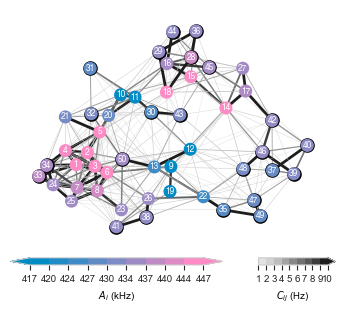

In [5]:
seed = 33
fig = plt.figure(figsize=[8.8/2.54, 8/2.54]) 

size = 15
c_bar_size = 4

gs = GridSpec(size,size, figure=fig)

ax = fig.add_subplot(gs[0:-1,:])
ax_cbar_freq = fig.add_subplot(gs[-1, :int(size/3*2)])
ax_cbar_coupling = fig.add_subplot(gs[-1,int(size/3*2)+1:])

# How to plot edges\n",
adj = c_matrix > c_min
c_cut = np.copy(c_matrix)
c_cut[c_matrix>c_max] = c_max
c_cut[c_matrix<c_min] = 0.
c_cut = c_cut / np.max(c_cut)

G = nx.from_numpy_matrix(c_cut, create_using = nx.MultiGraph())
new_G = nx.from_numpy_matrix(c_cut[27:,27:], create_using = nx.MultiGraph())

pos = nx.spring_layout(G, seed = seed)
new_keys = list(pos.keys())[27:]
new_pos ={}
for i, key in enumerate(new_keys):
    new_pos[i] = pos[key]

weights = nx.get_edge_attributes(G, 'weight')
edge_colors = cm.Greys(np.array(list(weights.values()))*(grey_max - grey_min) + grey_min)
edge_weights = np.array(list(weights.values()))*2

lab_label_list = list(df_positions['Lab label'])

labels = {}
lab_labels = {}
for i, key in enumerate(list(pos.keys())):
    labels[i] = key + 1
    lab_labels[i] = lab_label_list[i][1:]

    
nodes = nx.draw_networkx_nodes(new_G, new_pos, ax= ax, 
                               node_size=90, 
                               node_color='black',
                              )

nodes = nx.draw_networkx_nodes(G, pos, ax= ax, 
                               node_size=70, 
                               node_color=node_colors,
                              )


nx.draw_networkx_labels(G, pos, labels = labels,ax = ax,
                        font_size = 6,
                        font_family = 'Helvetica',
                        font_color = 'white'
                       
                       )

nx.draw_networkx_edges(G,pos, ax = ax,
                       edgelist = weights.keys(),
                       width=edge_weights,
                       edge_color=edge_colors,
                      )

ax.set_axis_off()

# Colorbar freqs\n",
cmap = mpl.colors.ListedColormap(node_colors_bar)
cmap.set_over(node_colors_bar[-1])
cmap.set_under(node_colors_bar[0])

bounds = np.round(np.linspace(freq_min*1e-3, freq_max*1e-3, 10),0)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
cb3 = mpl.colorbar.ColorbarBase(ax_cbar_freq, cmap=cmap,
                                norm=norm,
                                boundaries=  bounds ,
                                extend='both',
                                extendfrac='auto',
                                ticks=bounds,
                                spacing='uniform',
                                orientation='horizontal')
cb3.set_label('$A_i$ (kHz)')

# Colorbar couplings\n",
cmap = mpl.colors.ListedColormap(edge_colors_bar)
cmap.set_over(cm.Greys(grey_max))
cmap.set_under(cm.Greys(grey_min))

bounds = np.round(np.linspace(c_min, c_max, 10),0) 
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
cb3 = mpl.colorbar.ColorbarBase(ax_cbar_coupling, cmap=cmap,
                                norm=norm,
                                boundaries=  bounds ,
                                extend='max',
                                extendfrac='auto',
                                ticks=bounds,
                                spacing='uniform',
                                orientation='horizontal')
cb3.set_label('$C_{ij}$ (Hz)')

plt.tight_layout()
plt.show()


### Save figure

In [6]:
plt.savefig('figure_5.pdf', bbox_inches='tight')

### Latex table of spins

In [7]:
caption = 'Information on the nuclear spins mapped in this work. A dash denotes that no $\\deltah{i}$ signal could be obtained due to low polarisation, coherence, or readout contrast. Value in parentheses denotes standard deviation on the last digit.'

latex_text = df_table.to_latex(
    index = False,
    longtable= True,
    column_format = 'lllrrrrr',
    escape = False,
    caption = caption,
    multirow = True,
)

print(latex_text)

\begin{longtable}{lllrrrrr}
\caption{Information on the nuclear spins mapped in this work. A dash denotes that no $\deltah{i}$ signal could be obtained due to low polarisation, coherence, or readout contrast. Value in parentheses denotes standard deviation on the last digit.}\\
\toprule
Paper label & Lab label & Initialisation & Readout & $A_i$ (kHz) & $\Delta_i$ (Hz) & x (\AA) & y (\AA) & z (\AA) \\
\midrule
\endfirsthead
\caption[]{Information on the nuclear spins mapped in this work. A dash denotes that no $\deltah{i}$ signal could be obtained due to low polarisation, coherence, or readout contrast. Value in parentheses denotes standard deviation on the last digit.} \\
\toprule
Paper label & Lab label & Initialisation & Readout & $A_i$ (kHz) & $\Delta_i$ (Hz) & x (\AA) & y (\AA) & z (\AA) \\
\midrule
\endhead
\midrule
\multicolumn{9}{r}{{Continued on next page}} \\
\midrule
\endfoot

\bottomrule
\endlastfoot
         C1 &        C9 &       PulsePol & Chain-1 &   452.83(2) &     -208

/var/folders/bj/yvztxw3x02q7p94lvc80kqt4f5p5j8/T/ipykernel_62938/59123637.py:3: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_text = df_table.to_latex(


### Supplementary figure 3

<IPython.core.display.Javascript object>


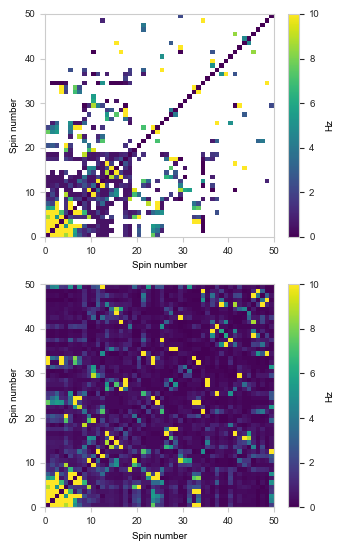

In [8]:
vmin = 0
vmax = 10
cmap = 'viridis'
fig, ax = plt.subplots(2,1, figsize=[8.8/2.54, 14/2.54])#, gridspec_kw={'width_ratios': [1, 1.15]})

pos0 = ax[0].pcolormesh(df_measured, vmin = vmin, vmax = vmax, cmap = cmap)
pos1 = ax[1].pcolormesh(df_predicted, vmin = vmin, vmax = vmax, cmap = cmap)

current_cmap = cm.get_cmap()
current_cmap.set_bad('grey')
# cmap.set_bad('grey')

# cax = plt.axes([0.85, 0.1, 0.075, 0.8])]
fig.colorbar(pos0, ax = ax[0], label = 'Hz')
fig.colorbar(pos1, ax = ax[1], label = 'Hz')

for i in range(len(ax)):
    ax[i].set_xlabel('Spin number')
    ax[i].set_ylabel('Spin number')
    ax[i].tick_params(color = axes_color )
    
plt.tight_layout()

### Save figure

In [9]:
plt.savefig('figure_s3.pdf', bbox_inches='tight')